# Notebook 3 — Experiment 2: Number of Transformer Layers

**Goal:** Train models with `n_layers ∈ {1, 3, 5, 7, 12}`, holding everything else fixed, and compare train/val loss curves to understand how architectural depth affects learning.

**Design choices (carried over from Notebooks 1–2):**
- **LR = 1e-3** — winning learning rate from Step 1's sweep
- **Max 15 epochs, patience=5** — Step 2 showed best val at epoch 10 on the 162M model with overfitting from epoch 11 onward; this window catches the best-val moment without burning compute on overfit territory
- **GPT-mini config** (emb_dim=384, n_heads=6) — ~4× faster than the 162M baseline used in Step 2; the relative differences between depth settings show up cleanly without overshadowing
- **Same prompt for generation samples** — `'The dawn is the head of the horse'` (matches Step 2 for consistent qualitative comparison)

**Estimated runtime:** ~10–15 min on RTX 4090. The 12-layer run takes roughly half of that on its own.


In [1]:
# ── Device setup (GPU) ──────────────────────────────────────────────
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device :", device)
if device.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))


PyTorch: 2.4.1+cu124
Device : cuda
GPU    : NVIDIA GeForce RTX 4090


### STEP 1: LOADING THE DATASET


In [2]:
import os

file_path = "A History of Indian Philosophy Volume 1.txt"

# Check if the file exists in the current directory (i.e., Colab session)
if os.path.exists(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        raw_text = file.read()
    print(f"File '{file_path}' loaded with {len(raw_text)} characters.")
else:
    print(f"File '{file_path}' not found. Please upload it to the Colab environment first.")


File 'A History of Indian Philosophy Volume 1.txt' loaded with 1342083 characters.


### STEP 2: IMPLEMENTING THE TOKENIZER


In [3]:
!pip3 install tiktoken > /dev/null 2>&1

In [4]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

tiktoken version: 0.12.0


In [5]:
tokenizer = tiktoken.get_encoding("gpt2")

In [6]:
total_characters = len(raw_text)
total_tokens = len(tokenizer.encode(raw_text))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 1342083
Tokens: 357340


### STEP 3: CREATING INPUT-TARGET PAIRS

In [7]:
with open("A History of Indian Philosophy Volume 1.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

357340


In [8]:
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [9]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [10]:
import torch
print("PyTorch version:", torch.__version__)
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

PyTorch version: 2.4.1+cu124
[tensor([[  464,  4935, 20336, 46566]]), tensor([[ 4935, 20336, 46566,   286]])]


### STEP 4: IMPLEMENTING MULTI-HEAD ATTENTION

In [11]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec

### STEP 5: IMPLEMENTING A GPT MODEL FROM SCRATCH TO GENERATE TEXT

In [12]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 256, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

### STEP 6: THE BUILDING BLOCKS-LAYER NORMALIZATION, GELU AND FEED-FORWARD NEURAL NETWORK

In [13]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))


class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), ## Expansion
            GELU(), ## Activation
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), ## Contraction
        )

    def forward(self, x):
        return self.layers(x)

In [14]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        # 2*4*768
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x
        # 2*4*768

### STEP 7: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION

In [15]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### STEP 8: GENERATING TEXT FROM OUTPUT TOKENS

In [16]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]

        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond) ### batch, n_tokens, vocab_size

        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        logits = logits[:, -1, :]

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [17]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)  # remove batch dimension
    return tokenizer.decode(flat.tolist())

### STEP 9: CREATING TRAINING, TESTING AND VALIDATION DATA

In [18]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(raw_text))
train_data = raw_text[:split_idx]
val_data = raw_text[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

### STEP 10: DEFINING THE CROSS ENTROPY LOSS FUNCTION

In [19]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GPTModel(GPT_CONFIG_124M)
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.983911429511176
Validation loss: 10.988269606632972


In [21]:
print(device)

cuda


### STEP 11: TRAINING LOOP FOR THE LLM

In [22]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [23]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [25]:
!pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python -m pip install --upgrade pip


In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

NameError: name 'num_epochs' is not defined

In [27]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

## EXPERIMENT 2 — Layer-depth sweep

All cells from here on are new for NB3. Everything above is identical to the setup in Notebooks 1–2 (data, model classes, helper functions).

In [28]:
import os, json, time
import torch
import matplotlib.pyplot as plt

# GPT-mini config: smaller than the 162M baseline used in Step 2.
# Same context_length (256) and dropout (0.1); emb_dim halved to 384,
# n_heads to 6. n_layers is what we'll sweep.
GPT_CONFIG_MINI = {
    'vocab_size':     50257,
    'context_length': 256,
    'emb_dim':        384,
    'n_heads':        6,
    'n_layers':       6,    # default; will be overridden in sweep
    'drop_rate':      0.1,
    'qkv_bias':       False,
}

# Sweep settings
NB3_LR             = 1e-3
NB3_MAX_EPOCHS     = 15
NB3_PATIENCE       = 5
NB3_LAYER_GRID     = [1, 3, 5, 7, 12]
NB3_CKPT_DIR       = 'nb3_layer_checkpoints'
NB3_RESULTS_FILE   = 'nb3_layer_results.json'

os.makedirs(NB3_CKPT_DIR, exist_ok=True)
print(f'Sweeping n_layers ∈ {NB3_LAYER_GRID} at lr={NB3_LR}')
print(f'Each model: max {NB3_MAX_EPOCHS} epochs, patience={NB3_PATIENCE}')
print(f'Checkpoints: {NB3_CKPT_DIR}/')


Sweeping n_layers ∈ [1, 3, 5, 7, 12] at lr=0.001
Each model: max 15 epochs, patience=5
Checkpoints: nb3_layer_checkpoints/


### Training loop with per-epoch logging

Same `train_with_epoch_logging` function as Step 2: full-val-set eval each epoch, early stop on patience, save best checkpoint.

In [29]:
def train_with_epoch_logging(
    model, train_loader, val_loader, optimizer, device,
    max_epochs, patience, ckpt_path, config,
    log_prefix='',
):
    """Train, log per-epoch losses, save best checkpoint."""
    train_losses, val_losses, epoch_times = [], [], []
    best_val_loss, best_val_epoch, epochs_since_best = float('inf'), -1, 0

    for epoch in range(1, max_epochs + 1):
        t0 = time.time()

        # Train one full epoch
        model.train()
        running, n = 0.0, 0
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            running += loss.item()
            n += 1
        train_loss = running / max(n, 1)

        # Full val eval
        model.eval()
        with torch.no_grad():
            val_loss = calc_loss_loader(val_loader, model, device)

        dt = time.time() - t0
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        epoch_times.append(dt)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_val_epoch = epoch
            epochs_since_best = 0
            torch.save({
                'epoch': epoch, 'val_loss': val_loss,
                'config': config, 'model_state': model.state_dict(),
            }, ckpt_path)
        else:
            epochs_since_best += 1

        marker = ' ★' if improved else ('  ' if epochs_since_best < patience else ' (stale)')
        print(f'  {log_prefix}Epoch {epoch:2d}/{max_epochs} | '
              f'train {train_loss:.4f} | val {val_loss:.4f} | '
              f'best {best_val_loss:.4f} @ ep{best_val_epoch} | '
              f'{dt:.1f}s{marker}')

        if epochs_since_best >= patience:
            print(f'  {log_prefix}Early stop at epoch {epoch} '
                  f'(no val improvement in {patience} epochs)')
            break

    return {
        'train_losses':   train_losses,
        'val_losses':     val_losses,
        'epoch_times':    epoch_times,
        'best_val_loss':  best_val_loss,
        'best_val_epoch': best_val_epoch,
        'last_epoch':     len(train_losses),
    }


### Run the layer-depth sweep

Trains 5 models, one per `n_layers` value in {1, 3, 5, 7, 12}. Each starts from the same seed (123), differs only in depth. Results aggregated for plotting in the next section.

In [30]:
nb3_results = {}   # n_layers -> {train_losses, val_losses, ...}

sweep_t0 = time.time()

for n_layers in NB3_LAYER_GRID:
    print(f'\n{"="*70}')
    print(f'Training GPT-mini with n_layers={n_layers}')
    print(f'{"="*70}')

    cfg = {**GPT_CONFIG_MINI, 'n_layers': n_layers}

    torch.manual_seed(123)
    model = GPTModel(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=NB3_LR, weight_decay=0.1)

    n_params = sum(p.numel() for p in model.parameters())
    print(f'  Params: {n_params:,}')

    ckpt_path = os.path.join(NB3_CKPT_DIR, f'best_layers{n_layers}.pt')
    res = train_with_epoch_logging(
        model=model, train_loader=train_loader, val_loader=val_loader,
        optimizer=optimizer, device=device,
        max_epochs=NB3_MAX_EPOCHS, patience=NB3_PATIENCE,
        ckpt_path=ckpt_path, config=cfg,
    )
    res['n_layers']    = n_layers
    res['n_params']    = n_params
    res['ckpt_path']   = ckpt_path
    res['config']      = cfg
    nb3_results[n_layers] = res

    print(f'  Done. Best val: {res["best_val_loss"]:.4f} @ epoch {res["best_val_epoch"]}')

    # Free GPU memory before next run
    del model, optimizer
    if device.type == 'cuda':
        torch.cuda.empty_cache()

sweep_min = (time.time() - sweep_t0) / 60
print(f'\n✅ Layer sweep done in {sweep_min:.1f} min')

# Save results JSON for the writeup
results_to_save = {str(k): {kk: vv for kk, vv in v.items() if kk != 'config'}
                   for k, v in nb3_results.items()}
with open(NB3_RESULTS_FILE, 'w') as f:
    json.dump(results_to_save, f, indent=2)
print(f'Saved results to {NB3_RESULTS_FILE}')



Training GPT-mini with n_layers=1
  Params: 40,469,760
  Epoch  1/15 | train 5.7028 | val 5.2989 | best 5.2989 @ ep1 | 5.3s ★
  Epoch  2/15 | train 4.5727 | val 5.0834 | best 5.0834 @ ep2 | 5.3s ★
  Epoch  3/15 | train 4.0811 | val 5.1202 | best 5.0834 @ ep2 | 5.0s  
  Epoch  4/15 | train 3.6905 | val 5.1962 | best 5.0834 @ ep2 | 5.0s  
  Epoch  5/15 | train 3.3749 | val 5.2666 | best 5.0834 @ ep2 | 5.0s  
  Epoch  6/15 | train 3.1079 | val 5.3600 | best 5.0834 @ ep2 | 5.0s  
  Epoch  7/15 | train 2.8751 | val 5.4484 | best 5.0834 @ ep2 | 5.0s (stale)
  Early stop at epoch 7 (no val improvement in 5 epochs)
  Done. Best val: 5.0834 @ epoch 2

Training GPT-mini with n_layers=3
  Params: 44,016,384
  Epoch  1/15 | train 5.6562 | val 5.2533 | best 5.2533 @ ep1 | 8.8s ★
  Epoch  2/15 | train 4.5902 | val 5.0715 | best 5.0715 @ ep2 | 10.7s ★
  Epoch  3/15 | train 4.1274 | val 5.0317 | best 5.0317 @ ep3 | 9.3s ★
  Epoch  4/15 | train 3.7253 | val 5.1422 | best 5.0317 @ ep3 | 9.2s  
  Epoch 

### Summary table

Best validation loss reached, the epoch it was reached at, parameter count, and total wall-clock time per configuration.

In [31]:
print(f'{"n_layers":>9} | {"params":>12} | {"best val":>10} | '
      f'{"@ epoch":>8} | {"final train":>12} | {"total s":>8}')
print('-' * 78)
for k in NB3_LAYER_GRID:
    r = nb3_results[k]
    total_s = sum(r['epoch_times'])
    print(f'{k:>9d} | {r["n_params"]:>12,} | {r["best_val_loss"]:>10.4f} | '
          f'{r["best_val_epoch"]:>8d} | {r["train_losses"][-1]:>12.4f} | '
          f'{total_s:>8.1f}')


 n_layers |       params |   best val |  @ epoch |  final train |  total s
------------------------------------------------------------------------------
        1 |   40,469,760 |     5.0834 |        2 |       2.8751 |     35.4
        3 |   44,016,384 |     5.0317 |        3 |       2.4799 |     74.8
        5 |   47,563,008 |     4.9885 |        3 |       2.6195 |    105.7
        7 |   51,109,632 |     5.0118 |        4 |       2.5644 |    142.1
       12 |   59,976,192 |     5.0436 |        4 |       3.4818 |    214.3


### Loss curves: side-by-side train and val

Standard assignment format: training loss on the left axis, validation loss on the right, all five depths overlaid in each pane.

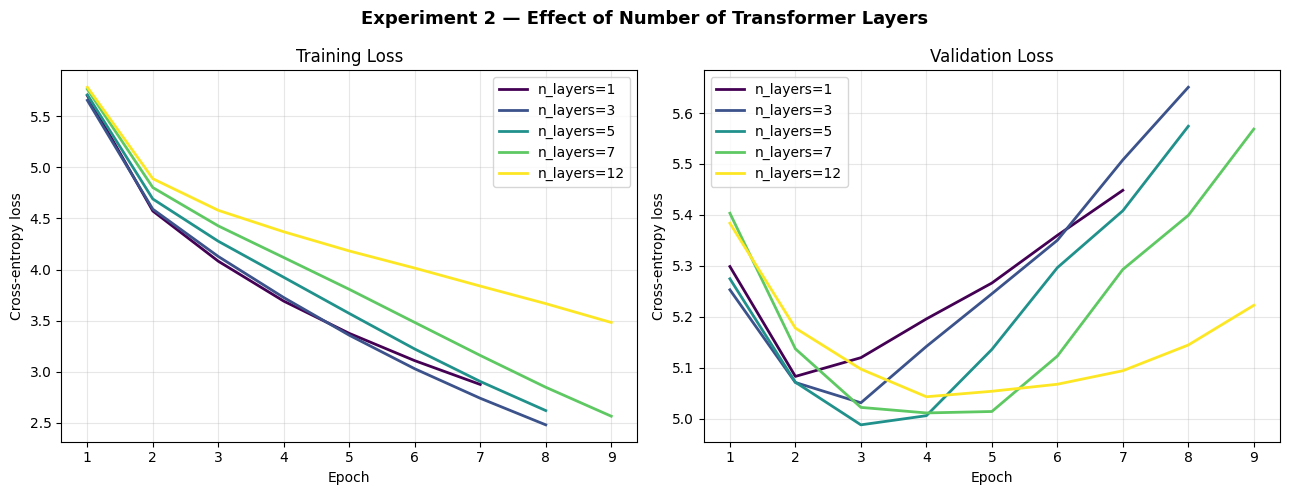

In [32]:
from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Experiment 2 — Effect of Number of Transformer Layers',
             fontsize=13, fontweight='bold')

colors = plt.cm.viridis([i/(len(NB3_LAYER_GRID)-1) for i in range(len(NB3_LAYER_GRID))])

for color, n_layers in zip(colors, NB3_LAYER_GRID):
    r = nb3_results[n_layers]
    epochs_x = list(range(1, len(r['train_losses']) + 1))
    label = f'n_layers={n_layers}'
    axes[0].plot(epochs_x, r['train_losses'], color=color, linewidth=2, label=label)
    axes[1].plot(epochs_x, r['val_losses'],   color=color, linewidth=2, label=label)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('nb3_layer_sweep_curves.pdf')
plt.savefig('nb3_layer_sweep_curves.png', dpi=150)
plt.show()


### Best validation loss vs. depth

Bar chart showing the lowest val loss reached by each depth setting. Makes the depth-vs-performance relationship a single glanceable picture.

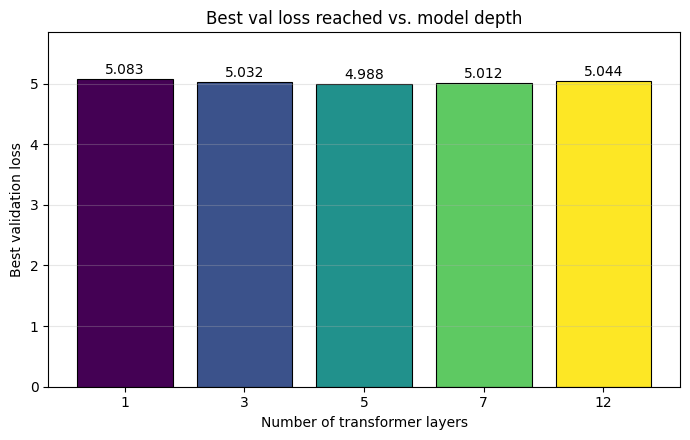

In [33]:
fig, ax = plt.subplots(figsize=(7, 4.5))
depths = NB3_LAYER_GRID
best_vals = [nb3_results[k]['best_val_loss'] for k in depths]

bars = ax.bar([str(d) for d in depths], best_vals,
              color=plt.cm.viridis([i/(len(depths)-1) for i in range(len(depths))]),
              edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, best_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{v:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Number of transformer layers')
ax.set_ylabel('Best validation loss')
ax.set_title('Best val loss reached vs. model depth')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(best_vals) * 1.15)
plt.tight_layout()
plt.savefig('nb3_layer_sweep_best_val.pdf')
plt.savefig('nb3_layer_sweep_best_val.png', dpi=150)
plt.show()


### Generation samples

Loads the best checkpoint of each depth setting and generates from a fixed prompt. Same prompt as Step 2 for cross-notebook consistency.

In [34]:
PROMPT = 'The dawn is the head of the horse'
MAX_NEW_TOKENS = 50

for n_layers in NB3_LAYER_GRID:
    ckpt_path = nb3_results[n_layers]['ckpt_path']
    if not os.path.exists(ckpt_path):
        print(f'\n[n_layers={n_layers}] checkpoint missing — skipping')
        continue
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    m = GPTModel(ckpt['config']).to(device)
    m.load_state_dict(ckpt['model_state'])
    m.eval()

    ids = text_to_token_ids(PROMPT, tokenizer).to(device)
    with torch.no_grad():
        out = generate(
            model=m, idx=ids,
            max_new_tokens=MAX_NEW_TOKENS,
            context_size=ckpt['config']['context_length'],
            top_k=25, temperature=1.4,
        )
    text = token_ids_to_text(out, tokenizer)
    print(f'\n=== n_layers={n_layers} '
          f'(epoch {ckpt["epoch"]}, val {ckpt["val_loss"]:.4f}) ===')
    print(text)

    del m
    if device.type == 'cuda':
        torch.cuda.empty_cache()



=== n_layers=1 (epoch 2, val 5.0834) ===
The dawn is the head of the horse, or to them the time which it, but it has but he was
that it as being or demer_ has been revealed it may be comprehendence or
itâcitthavaikara-consciousness to be made as we

=== n_layers=3 (epoch 3, val 5.0317) ===
The dawn is the head of the horse (2.

of the soul and as in order that "a is not." There the jug "The gu@sa is not" cannot mean the jug and not a result which produces
of it in common, "there is
which

=== n_layers=5 (epoch 3, val 4.9885) ===
The dawn is the head of the horse that they is only in the perception. But there or "a or is said that
it. There is a case of this," he could not
knowledge which can neither
or appearance. Karma cannot be
or mere illusion or non-et

=== n_layers=7 (epoch 4, val 5.0118) ===
The dawn is the head of the horse of a very very important
as or that
which must be inferred. On each case that a permanent knowledge was not
in a unique, that would exist in
perceived. It,


### Download before terminating the pod

```bash
cd /workspace && tar czf nb3_results.tar.gz \
    Notebook3_Layers.ipynb \
    nb3_layer_results.json \
    nb3_layer_checkpoints/ \
    nb3_layer_sweep_curves.pdf nb3_layer_sweep_curves.png \
    nb3_layer_sweep_best_val.pdf nb3_layer_sweep_best_val.png
```
